# Zadanie: porównanie metod klasteringu

## Pytania 
1) Czy potrzeba wszystkich cech?
2) Czy potrzebna jest jakaś obróbka?
3) Czy wiemy, jak obrobić?
4) Czy wiemy, co jaka cecha znaczy?
5) Czy potrzebujemy aż dwóch plików?
6) Pamiętajmy, że mamy do czynienia z Unsupervised Learning. Czy podział na dane testowe i treningowe jest potrzebny, jeśli tak to dlaczego, jeśli nie to dlaczego?
7) czym różni się KMeans, K-fold i K Nearest Neighbors 

## Odpowiedzi
1) Nie, nie potrzebujemy wszystkich cech jest ich 560 a wiele z nich niesie tą samą informacje.
2) Skalowanie + algorytm PCA w celu zmniejszenia liczby cech
3) Najlepiej przy pomocy piplinu, dzięki czemu można dowolnie i szybko modyfikować kroki.
4) Nie wiemy i nie musimy, a po użyciu PCA i tak cechy się zmieniają
5) Do klasteryzacji nie potrzebujemy, ale do uczenia nadzorowanego trzeba je znowu rozdzielić. 
6) Przy Unsupervised Learning podział na test/train nie ma sensu ponieważ algorytm nie dostaje odpowiedzi a dzięki połaczeniu danych może lepiej dopasować klastry. Przy Supervised Learning należy podzielić ponieważ w innym wypadku doszło by do data leak a co za tym idzie fałszywie wysoki wynik. 
7) KMeans jest modelem klasyfikacji służącym do przydzielania danych do odpowiedniego klastra, K Nearest Neighbors (KNN) jest modelem Supervised Learning natomiast K-fold to walidacja krzyżowa czyli podział danych treningowych na części a następnie uczenie modelu w taki sposób by każda z części raz była częścią testową a w pozostałych treningową, wynikiem jest średnia z wyników.

Importy bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.mixture import GaussianMixture
from sklearn.base import BaseEstimator, TransformerMixin

import danych z plików

In [2]:
X_test = pd.read_csv('samsung_test.txt', sep='\\s+', header=None)
X_train = pd.read_csv('samsung_train.txt', sep='\\s+', header=None)
y_test = pd.read_csv('samsung_test_labels.txt', sep='\\s+', header=None)
y_train = pd.read_csv('samsung_train_labels.txt', sep='\\s+', header=None)

y_train_flat = y_train.values.ravel()
y_test_flat = y_test.values.ravel()

Własny transformer do obsługi klasteryzacji w potokach.

In [3]:
class ClusterFeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self, clusterer):
        self.clusterer = clusterer
        
    def fit(self, X, y=None):
        if hasattr(self.clusterer, 'fit'):
            self.clusterer.fit(X)
        return self
        
    def transform(self, X):
        if isinstance(self.clusterer, DBSCAN):
            labels = self.clusterer.fit_predict(X)
        elif hasattr(self.clusterer, 'predict'):
            labels = self.clusterer.predict(X)
        else:
            labels = self.clusterer.fit_predict(X)
            
        return np.column_stack((X, labels))

Słownik modeli klasteryzacji oraz none dodane by mozna było porównać z zbiorami bez klasteryzacji

Używam tutaj n_clusters=20 ponieważ dane z sensorów ruchu mocna na siebie nachodzą, Kmeans słabo radzi sobie z takimi danymi, dlatego zamiast dzielić dane na 6 klastrów, lepszym rozwiazaniem jest zwiększenie ich liczby względem ilości prawdziwych grup. Mniejsze grupy mogą pomóc w przypisaniu. Dane zbyt na siebie nachodzą by podział na wieksze klastry nie powodował błednego łączenia w grupy kilku aktywności, co zamiast pomagać mogło by zaszkodzić. Mniejsze klastry zbierają w grupe tylko bliskie sobie dane więc mogą dać dodatkowe informacje dla modelu. 

In [4]:
clusterers = {
    "Bez klasteringu": None,  # None oznacza, że pominiemy ten krok w Pipeline
    "Z KMeans": ClusterFeatureAdder(KMeans(n_clusters=20, random_state=42)),
    "Z DBSCAN": ClusterFeatureAdder(DBSCAN(eps=14.5, min_samples=5)),
    "Z GMM": ClusterFeatureAdder(GaussianMixture(n_components=6, random_state=42))
}

Słownik modeli nadzorowanych

In [5]:
Modele = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=2),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

zagnieżdzona pętla służąca do nauki modelów bez, oraz z dodatkową cechą uzyskaną dzięki klasteryzacji.

In [6]:
print(f"{'Klasyfikator':<25} | {'Klasteryzacja':<18} | {'Wynik (Accuracy)':<15}")
print("-" * 70)
piplines = {}
for clf_name, clf_obj in Modele.items():
    for cl_name, cl_obj in clusterers.items():
        
        steps = [('scaler', StandardScaler()),('pca', PCA(n_components=0.95, random_state=42))]
        if cl_obj is not None:
            steps.append(('clustering', cl_obj))
            
        steps.append(('classifier', clf_obj))
        pipeline = Pipeline(steps)
        pipeline.fit(X_train, y_train_flat)
        score = pipeline.score(X_test, y_test_flat)
        
        print(f"{clf_name:<25} | {cl_name:<18} | {score:.4f}")

        if clf_name == "Logistic Regression":
            piplines[cl_name] = pipeline

Klasyfikator              | Klasteryzacja      | Wynik (Accuracy)
----------------------------------------------------------------------
Logistic Regression       | Bez klasteringu    | 0.9308
Logistic Regression       | Z KMeans           | 0.9321
Logistic Regression       | Z DBSCAN           | 0.9274
Logistic Regression       | Z GMM              | 0.9304
Decision Tree             | Bez klasteringu    | 0.7564
Decision Tree             | Z KMeans           | 0.7631
Decision Tree             | Z DBSCAN           | 0.7682
Decision Tree             | Z GMM              | 0.7635
Random Forest             | Bez klasteringu    | 0.8806
Random Forest             | Z KMeans           | 0.8850
Random Forest             | Z DBSCAN           | 0.8799
Random Forest             | Z GMM              | 0.8816
SVM                       | Bez klasteringu    | 0.9379
SVM                       | Z KMeans           | 0.9355
SVM                       | Z DBSCAN           | 0.9362
SVM                    

Możemy zauważyć że klasteryzacja pomaga jednak nie każda i nie w każdym modelu. Dodatkowo należy pamiętać że modele uczyły się danych już po wykorzystaniu PCA co mimo ustawienia n_components=0.95 powoduje odcięcie wartości odstających co może powodować spadek jakości modelów. Mimo zmniejszenia liczby cech z 560 do niewiele ponad 100 nadal widać że drzewo decyzyjne nie rodzi sobie zbyt dobrze, za to SVM który radzi sobie najlepiej ze wszystkich modeli po wykorzystaniu klasteryzacji radzi sobie gorzej niż bez. 

Wyciągnięcie danych z zapisanych piplinów w celu ponownego przekształcenia ich przy pomocy algorytmu PCA do postaci 2 wymiarowych i naniesienia na wykresy przedstawiające uproszczony podział danych na klastry.

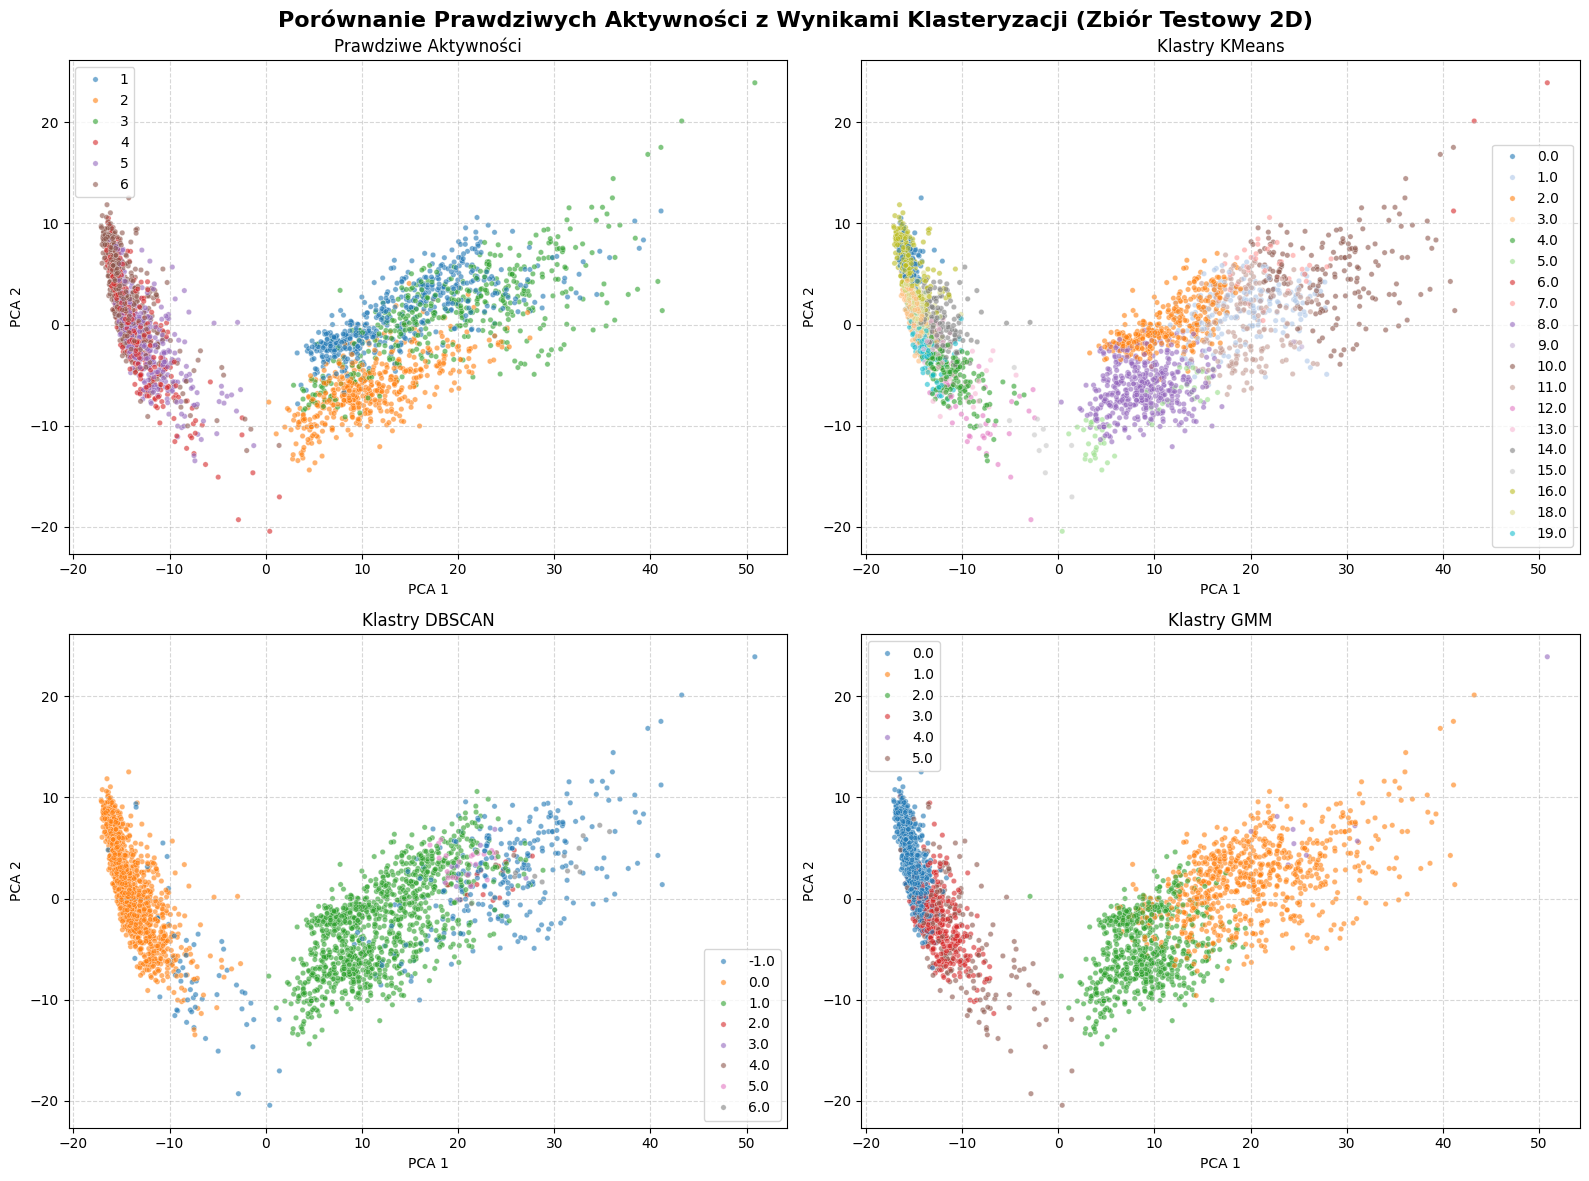

In [7]:
base_pipeline = piplines["Bez klasteringu"]

X_test_scaled = base_pipeline.named_steps['scaler'].transform(X_test)
X_test_pca_full = base_pipeline.named_steps['pca'].transform(X_test_scaled)
X_test_2D = X_test_pca_full[:, :2]

km_labels_test = piplines["Z KMeans"].named_steps['clustering'].transform(X_test_pca_full)[:, -1]
db_labels_test = piplines["Z DBSCAN"].named_steps['clustering'].transform(X_test_pca_full)[:, -1]
gmm_labels_test = piplines["Z GMM"].named_steps['clustering'].transform(X_test_pca_full)[:, -1]


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Porównanie Prawdziwych Aktywności z Wynikami Klasteryzacji (Zbiór Testowy 2D)", fontsize=16, fontweight='bold')

sns.scatterplot(x=X_test_2D[:, 0], y=X_test_2D[:, 1], hue=y_test_flat, palette="tab10", ax=axes[0, 0], alpha=0.6, s=15)
axes[0, 0].set_title("Prawdziwe Aktywności")
sns.scatterplot(x=X_test_2D[:, 0], y=X_test_2D[:, 1], hue=km_labels_test, palette="tab20", ax=axes[0, 1], alpha=0.6, s=15)
axes[0, 1].set_title("Klastry KMeans")
sns.scatterplot(x=X_test_2D[:, 0], y=X_test_2D[:, 1], hue=db_labels_test, palette="tab10", ax=axes[1, 0], alpha=0.6, s=15)
axes[1, 0].set_title("Klastry DBSCAN")
sns.scatterplot(x=X_test_2D[:, 0], y=X_test_2D[:, 1], hue=gmm_labels_test, palette="tab10", ax=axes[1, 1], alpha=0.6, s=15)
axes[1, 1].set_title("Klastry GMM")


for ax in axes.flat:
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

jak widać na wykresie prawdziwych aktywności widać 2 grupy aktywności, bardziej zwarty obszar zawierający siedzenie, stanie i leżenie oraz bardziej rozbity i szeroki obszar dla marszu, wchodzenia i schodzenia po schodach. Modele nie maja problemów z oddzieleniem tych 2 grup, jednak podział na poszczególne aktywności już tak dobrze im nie wychodzi. Wyjątkiem jest tutaj KMeans który dzięki utworzeniu aż 20 klastrów podzielił dane na podgrupy które faktycznie mogą pomóc przy uczeniu. 

Utowrzenie 2 piplinów w celu wykorzystania GridSearch do znaleznienia najlepszych hiperparametrów.

In [9]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('clustering', ClusterFeatureAdder(KMeans(n_clusters=20, random_state=42))),
    ('classifier', LogisticRegression(max_iter=5000, random_state=2))
])
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('clustering', ClusterFeatureAdder(KMeans(n_clusters=20, random_state=42))),
    ('classifier', SVC(random_state=42))
])


param_grid_lr = {'classifier__C': [0.1, 1.0, 10.0], 'classifier__penalty': ['l2']}
param_grid_svm = {'classifier__C': [0.1, 1.0, 10.0],'classifier__gamma': ['scale', 'auto']}


grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=3, n_jobs=-1, scoring='accuracy')
grid_lr.fit(X_train, y_train_flat)
y_pred_lr = grid_lr.predict(X_test)

grid_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=3, n_jobs=-1, scoring='accuracy')
grid_svm.fit(X_train, y_train_flat)
y_pred_svm = grid_svm.predict(X_test)

print(f"Najlepszy wynik LR: {accuracy_score(y_test_flat, y_pred_lr):.4f}")
print(f"Najlepszy wynik SVM: {accuracy_score(y_test_flat, y_pred_svm):.4f}")


print("LogisticRegression")
print(classification_report(y_test_flat, y_pred_lr))

print("\n=== Końcowy raport klasyfikacji dla najlepszego modelu (SVM) ===")
print(classification_report(y_test_flat, y_pred_svm))

C:\Users\www\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Najlepszy wynik LR: 0.9321
Najlepszy wynik SVM: 0.9396
LogisticRegression
              precision    recall  f1-score   support

           1       0.93      0.98      0.95       496
           2       0.91      0.91      0.91       471
           3       0.95      0.89      0.92       420
           4       0.92      0.87      0.89       491
           5       0.88      0.93      0.91       532
           6       1.00      0.99      1.00       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947


=== Końcowy raport klasyfikacji dla najlepszego modelu (SVM) ===
              precision    recall  f1-score   support

           1       0.95      0.97      0.96       496
           2       0.90      0.93      0.92       471
           3       0.95      0.90      0.93       420
           4       0.94      0.88      0.91       491
           5       0.90      0.95      0.92   

Widać tutaj że w przypadku Regresji logistycznej nie ma zysków precyzji, za to przy SVM widać lekki zysk z 0.9355 bez GridSearch do 0.9396 z GridSearch.